<a href="https://colab.research.google.com/github/Rahamatunnisa1121/Object-Recognition-System/blob/main/object_recog_sys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
unzip:  cannot find or open /content/drive/MyDrive/vegetables_dataset.zip, /content/drive/MyDrive/vegetables_dataset.zip.zip or /content/drive/MyDrive/vegetables_dataset.zip.ZIP.


In [ ]:
dataset_path="/content/drive/MyDrive/vegetables_dataset" # to tell python where my dataset is located

In [ ]:
import tensorflow as tf #for deep learning(image recog) and image dataset loading, training the model
import os #for handling file paths
import cv2 #opencv for image processing
import matplotlib.pyplot as plt # for image visualization

In [ ]:
#define dataset paths
train_dir=os.path.join(dataset_path,"train")
test_dir=os.path.join(dataset_path,"test")
val_dir=os.path.join(dataset_path,"validation")

In [ ]:
#load datasets
train_ds=tf.keras.preprocessing.image_dataset_from_directory(train_dir,image_size=(224,224),batch_size=32,shuffle=True)
#all the apple folder image contents will now have the name of the folder -> apple
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=(224, 224), batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=(224, 224), batch_size=32
)

Found 3115 files belonging to 36 classes.
Found 359 files belonging to 36 classes.
Found 351 files belonging to 36 classes.


In [ ]:
#EDA - Count classes and images
class_names=train_ds.class_names
num_classes=len(class_names)
print(f"Number of classes:{num_classes}")
print(f"Classes: {class_names}")

Number of classes:36
Classes: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [ ]:
train_count=sum([len(files) for _,_,files in os.walk(train_dir)]) #total images in train_dir
print(f"Total training images: {train_count}")

Total training images: 3115


In [ ]:
test_count = sum([len(files) for _, _, files in os.walk(test_dir)])
val_count = sum([len(files) for _, _, files in os.walk(val_dir)])
print(f"Total test images: {test_count}")
print(f"Total validation images: {val_count}")

Total test images: 359
Total validation images: 351


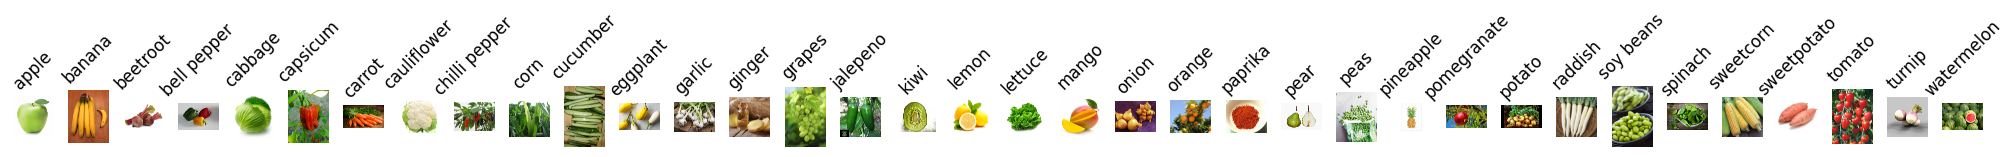

In [ ]:
#Display one image per class
fig, axes = plt.subplots(1, num_classes, figsize=(20, 10))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path) # Reads the image using OpenCV
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[i].imshow(image)
    axes[i].set_title(class_name, fontsize=12, rotation=45)
    axes[i].axis("off")

plt.tight_layout() #prevent overlaps
plt.show()

In [ ]:
import os
class_names = sorted(os.listdir(train_dir))
print("In train directory")
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [img for img in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, img))]
    print(f"Class: {class_name}, Number of Images: {len(image_files)}")

In train directory
Class: apple, Number of Images: 68
Class: banana, Number of Images: 75
Class: beetroot, Number of Images: 88
Class: bell pepper, Number of Images: 90
Class: cabbage, Number of Images: 92
Class: capsicum, Number of Images: 89
Class: carrot, Number of Images: 82
Class: cauliflower, Number of Images: 79
Class: chilli pepper, Number of Images: 87
Class: corn, Number of Images: 87
Class: cucumber, Number of Images: 94
Class: eggplant, Number of Images: 84
Class: garlic, Number of Images: 92
Class: ginger, Number of Images: 68
Class: grapes, Number of Images: 100
Class: jalepeno, Number of Images: 88
Class: kiwi, Number of Images: 88
Class: lemon, Number of Images: 82
Class: lettuce, Number of Images: 97
Class: mango, Number of Images: 86
Class: onion, Number of Images: 94
Class: orange, Number of Images: 69
Class: paprika, Number of Images: 83
Class: pear, Number of Images: 89
Class: peas, Number of Images: 100
Class: pineapple, Number of Images: 99
Class: pomegranate, Nu

In [ ]:
import os
class_names = sorted(os.listdir(test_dir))
print("In test directory")
for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    image_files = [img for img in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, img))]
    print(f"Class: {class_name}, Number of Images: {len(image_files)}")

In test directory
Class: apple, Number of Images: 10
Class: banana, Number of Images: 9
Class: beetroot, Number of Images: 10
Class: bell pepper, Number of Images: 10
Class: cabbage, Number of Images: 10
Class: capsicum, Number of Images: 10
Class: carrot, Number of Images: 10
Class: cauliflower, Number of Images: 10
Class: chilli pepper, Number of Images: 10
Class: corn, Number of Images: 10
Class: cucumber, Number of Images: 10
Class: eggplant, Number of Images: 10
Class: garlic, Number of Images: 10
Class: ginger, Number of Images: 10
Class: grapes, Number of Images: 10
Class: jalepeno, Number of Images: 10
Class: kiwi, Number of Images: 10
Class: lemon, Number of Images: 10
Class: lettuce, Number of Images: 10
Class: mango, Number of Images: 10
Class: onion, Number of Images: 10
Class: orange, Number of Images: 10
Class: paprika, Number of Images: 10
Class: pear, Number of Images: 10
Class: peas, Number of Images: 10
Class: pineapple, Number of Images: 10
Class: pomegranate, Number

In [ ]:
import os
class_names = sorted(os.listdir(val_dir))
print("In test directory")
for class_name in class_names:
    class_path = os.path.join(val_dir, class_name)
    image_files = [img for img in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, img))]
    print(f"Class: {class_name}, Number of Images: {len(image_files)}")

In test directory
Class: apple, Number of Images: 10
Class: banana, Number of Images: 9
Class: beetroot, Number of Images: 10
Class: bell pepper, Number of Images: 9
Class: cabbage, Number of Images: 10
Class: capsicum, Number of Images: 10
Class: carrot, Number of Images: 9
Class: cauliflower, Number of Images: 10
Class: chilli pepper, Number of Images: 9
Class: corn, Number of Images: 10
Class: cucumber, Number of Images: 10
Class: eggplant, Number of Images: 10
Class: garlic, Number of Images: 10
Class: ginger, Number of Images: 10
Class: grapes, Number of Images: 9
Class: jalepeno, Number of Images: 9
Class: kiwi, Number of Images: 10
Class: lemon, Number of Images: 10
Class: lettuce, Number of Images: 9
Class: mango, Number of Images: 10
Class: onion, Number of Images: 10
Class: orange, Number of Images: 9
Class: paprika, Number of Images: 10
Class: pear, Number of Images: 10
Class: peas, Number of Images: 10
Class: pineapple, Number of Images: 10
Class: pomegranate, Number of Ima